# Simulating the 2026 World Cup 50,000 times — an annotated rebuild

This notebook reconstructs the model behind Francisco Baquero's *Fútbol Analytics* post
[*"Mundial 2026: simulé el torneo 50.000 veces"*](https://patcheau.wordpress.com/2026/05/23/mundial-2026-simule-el-torneo-50-000-veces-y-esto-fue-lo-que-encontre/),
end to end, with the reasoning spelled out so you can see *why* each piece is built the way it is.

**The pipeline has five stages:**

1. **Data** — every international men's match since 1872 (Mart Jürisoo's public dataset).
2. **Ratings** — turn that match history into an **ELO** rating per national team.
3. **Match model** — turn two ELO ratings into probabilities: win/draw/loss, exact scorelines (Poisson), and a penalty coin.
4. **Tournament rules** — encode the *new* 48-team format (12 groups of 4, top 2 + 8 best thirds, then a 32-team knockout).
5. **Monte Carlo** — replay the whole tournament tens of thousands of times and read the frequencies as probabilities.

> A framing the author insists on, and worth keeping in mind: this is a **simulation** model, not a **forecast**.
> It does not predict a single outcome. It maps the distribution of outcomes that the historical record implies.


## A note on what's reproducible

Two parts of the original are pinned down, two parts you should expect to differ slightly:

- **Pinned:** the tournament *format* and the confirmed *group draw* (hard-coded below from the official December 2025 draw + March 2026 playoff results).
- **Approximate:** the exact ELO numbers (they depend on K-factor scales, the initial rating, and the data cut-off date) and FIFA's full third-place→bracket *lookup table* (495 possible combinations — we use a principled simplification, flagged where it happens).

So your champion percentages will land *near* the article's, not exactly on them. The qualitative story — Spain favourite, Argentina close behind, Colombia surprisingly high — is what reproduces robustly.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

# One RNG, seeded, so the whole notebook is reproducible.
SEED = 2026
rng = np.random.default_rng(SEED)

pd.set_option("display.max_rows", 60)
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## 1. The data

The starting point is the GitHub repo **`martj42/international_results`** — a public, MIT-licensed CSV
that records essentially every international men's match from Scotland–England (30 Nov 1872) to the present.
It's the de-facto standard dataset for this kind of model.

Columns we care about: `date`, `home_team`, `away_team`, `home_score`, `away_score`, `tournament`, `neutral`.

> **Network note:** this cell downloads ~50k rows over HTTP. If you're offline or behind a proxy, download
> `results.csv` from the repo manually and point `pd.read_csv` at the local file instead.


In [2]:
URL = "https://raw.githubusercontent.com/martj42/international_results/master/results.csv"

matches = pd.read_csv(URL, parse_dates=["date"])

# The author anchors the ratings at "March 2026", so we cut the history there.
# This makes the run reproducible and matches the article's reference point.
CUTOFF = pd.Timestamp("2026-03-31")
matches = matches[matches["date"] <= CUTOFF].copy()
matches = matches.dropna(subset=["home_score", "away_score"]).reset_index(drop=True)

print(f"{len(matches):,} matches from {matches['date'].min().date()} to {matches['date'].max().date()}")
matches.tail(3)

49,257 matches from 1872-11-30 to 2026-03-31


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
49254,2026-03-31,Cameroon,China PR,2.0,0.0,FIFA Series,Melbourne,Australia,True
49255,2026-03-31,Australia,Curaçao,5.0,1.0,FIFA Series,Melbourne,Australia,False
49256,2026-03-31,Kazakhstan,Comoros,1.0,0.0,FIFA Series,Astana,Kazakhstan,False


## 2. The ELO rating system

ELO is the chess-rating idea: every team carries a number that rises when it wins and falls when it loses,
and **the size of the move scales with how surprising the result was**. Beating a much weaker team barely
moves your rating; beating a much stronger one moves it a lot.

### The two formulas

**(a) Expected result.** Before a match, the probability team A "scores" (1 for a win, ½ for a draw) is the logistic curve

$$ W_e = \frac{1}{1 + 10^{-(R_A - R_B)/400}} $$

The `/400` is the ELO convention: a 400-point edge means ~10:1 expected dominance.

**(b) The update.** After the match,

$$ R_A \leftarrow R_A + K \cdot G \cdot (W - W_e) $$

where `W` is the actual result (1 / 0.5 / 0), `K` is the match-importance weight, and `G` is a goal-margin multiplier.
`(W - W_e)` is the *surprise*: positive if you did better than expected, negative if worse.

### The three modelling choices

- **K-factor (match importance).** A friendly is not a World Cup final. Following the article:
  `20` friendlies, `50` World Cup matches, with intermediate weights for qualifiers and continental cups.
- **Home advantage.** `+100` points added to the home side's rating *inside the expectation only* (not on neutral grounds).
- **Goal-difference multiplier `G`.** A 4–0 should count more than a 1–0 — but not four times more.
  A **logarithmic** multiplier compresses big wins: `G = 1 + ln(|goal_diff|)` (so 1→1.00, 2→1.69, 3→2.10, 4→2.39).


In [3]:
def k_factor(tournament: str) -> float:
    """Match-importance weight. Bigger K => ratings react faster to this match."""
    t = str(tournament).lower()
    if "friendly" in t:
        return 20.0
    if "fifa world cup" == t or t == "fifa world cup":
        return 50.0
    if "world cup" in t and "qual" in t:        # WC qualifiers
        return 40.0
    if "world cup" in t:                         # WC finals + related
        return 50.0
    if any(k in t for k in ["copa am", "uefa euro", "african cup",
                            "asian cup", "gold cup", "confederations"]):
        return 40.0                              # continental finals
    if "qualif" in t:                            # other qualifiers
        return 35.0
    return 30.0                                   # everything else


def goal_multiplier(goal_diff: int) -> float:
    """Logarithmic margin-of-victory weight; 1-goal games are the baseline."""
    g = abs(goal_diff)
    if g <= 1:
        return 1.0
    return 1.0 + np.log(g)


def expected_score(elo_a, elo_b, home_adv=0.0):
    """Logistic ELO expectation for team A (the /400 convention)."""
    return 1.0 / (1.0 + 10 ** (-((elo_a + home_adv) - elo_b) / 400.0))

import math

HALF_LIFE_DAYS = 365 * 2.5  # rating "half-forgets" a match after ~4 years

def time_weight(match_date, reference_date):
    """Exponential decay: weight=1.0 today, weight=0.5 after HALF_LIFE_DAYS."""
    days_ago = (reference_date - match_date).days
    return math.exp(-math.log(2) * days_ago / HALF_LIFE_DAYS)

### Building the ratings

We start everyone at **1500** (the chess convention) and walk through history match by match,
updating both teams after each game. With ~150 years of data the arbitrary starting value washes out
and the ratings settle into a meaningful spread. New teams that appear later also start at 1500.


In [4]:
HOME_FIELD = 100.0   # ELO points added to the home team's expectation
START_ELO = 1500.0

REFERENCE = pd.Timestamp("2026-03-31")

elo = defaultdict(lambda: START_ELO)

# itertuples is ~10x faster than iterrows for a loop this size.
for m in matches.itertuples(index=False):
    home, away = m.home_team, m.away_team
    hs, as_ = int(m.home_score), int(m.away_score)
    neutral = bool(m.neutral)

    ra, rb = elo[home], elo[away]
    adv = 0.0 if neutral else HOME_FIELD

    we_home = expected_score(ra, rb, adv)        # expected "score" for home
    if hs > as_:
        w_home = 1.0
    elif hs < as_:
        w_home = 0.0
    else:
        w_home = 0.5

    k = k_factor(m.tournament)* time_weight(m.date, REFERENCE)
    g = goal_multiplier(hs - as_)
    delta = k * g * (w_home - we_home)

    # Zero-sum update: whatever home gains, away loses.
    elo[home] = ra + delta
    elo[away] = rb - delta

ELO = dict(elo)
print(f"Rated {len(ELO):,} national teams.")

Rated 336 national teams.


Let's look at the top of the table and eyeball it against the article
(Spain ~2238, Argentina ~2209, France ~2153, Brazil ~2091, England ~2090, Colombia ~2081).
Exact numbers will drift with the K-scale and cut-off, but the ordering near the top should look familiar.

In [5]:
ranking = (pd.Series(ELO, name="ELO")
             .sort_values(ascending=False)
             .round(0).astype(int)
             .rename_axis("team")
             .reset_index())
ranking.index += 1
ranking.head(20)

,team,ELO
1,Spain,1890
2,Morocco,1863
3,France,1816
4,Argentina,1814
5,Japan,1813
6,England,1813
7,Senegal,1808
8,Nigeria,1791
9,Algeria,1790
10,Australia,1760


## 3. From ratings to a match model

ELO gives us a single expectation number. A football match needs more than that — we need
**win/draw/loss** probabilities, and for the group stage we need **exact scorelines** (to break ties on
goal difference and to rank third-placed teams across groups).

### (a) Win / Draw / Loss

The trick: ELO's expected score already equals `P(win) + ½·P(draw)`. So if we model the **draw probability**
separately, the win and loss probabilities fall out.

Draws are *most* likely between evenly matched teams and rare in mismatches. We model that with an
exponential decay in the rating gap: ~30% when teams are equal, decaying toward ~8% for large gaps.


In [6]:
def draw_probability(elo_diff):
    """Draw prob as a decaying function of |rating gap|: ~0.30 equal -> ~0.08 wide."""
    return 0.08 + 0.22 * np.exp(-abs(elo_diff) / 200.0)


def wdl_probabilities(elo_a, elo_b, home_adv=0.0):
    """Return (P(A win), P(draw), P(B win)). Uses E[score] = P(win) + 0.5*P(draw)."""
    e_a = expected_score(elo_a, elo_b, home_adv)
    p_draw = draw_probability((elo_a + home_adv) - elo_b)
    p_a = e_a - 0.5 * p_draw
    p_b = 1.0 - p_draw - p_a
    p_a, p_b = max(p_a, 1e-9), max(p_b, 1e-9)   # numerical floor
    s = p_a + p_draw + p_b
    return p_a / s, p_draw / s, p_b / s

Quick sanity check — a clear favourite, and two equals:

In [7]:
for a, b in [("Spain", "Colombia"), ("Brazil", "Brazil")]:
    pa, pd_, pb = wdl_probabilities(ELO.get(a, 1800), ELO.get(b, 1800))
    print(f"{a:8} vs {b:8}:  win {pa:.2f}  draw {pd_:.2f}  loss {pb:.2f}")

Spain    vs Colombia:  win 0.63  draw 0.18  loss 0.19
Brazil   vs Brazil  :  win 0.35  draw 0.30  loss 0.35


Here's the draw curve itself — the shape that says "draws happen between equals, not in mismatches":

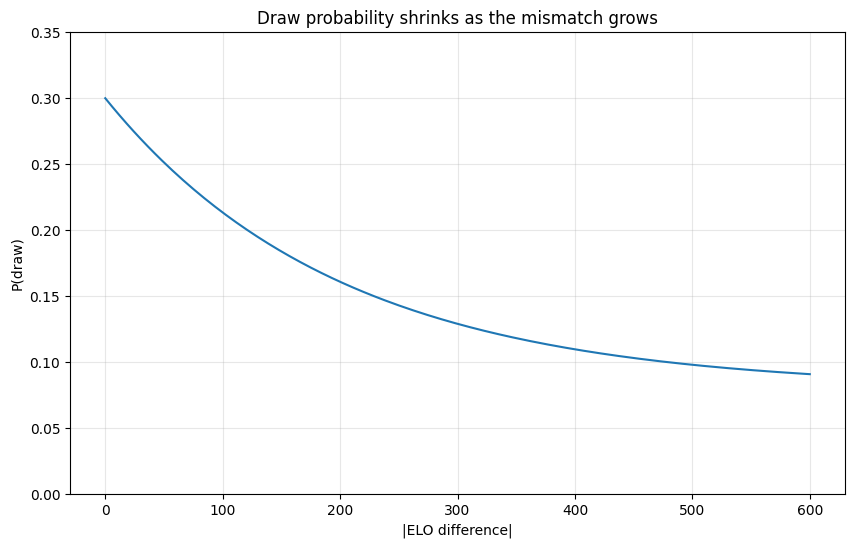

In [8]:
diffs = np.linspace(0, 600, 200)
plt.plot(diffs, [draw_probability(d) for d in diffs])
plt.xlabel("|ELO difference|")
plt.ylabel("P(draw)")
plt.title("Draw probability shrinks as the mismatch grows")
plt.ylim(0, 0.35)
plt.show()

### (b) Exact scorelines (Poisson)

Goals in football are well-approximated by a **Poisson process**: events arriving at a roughly constant rate.
So each team's goal count is `Poisson(λ)`, with the two teams' draws **independent**.

We pin the *total* expected goals to the historical average (~**2.65** per match) and split that total
between the teams according to their win expectation — the favourite gets the larger share of the goal budget.


In [9]:
GOALS_TOTAL = 2.65   # historical mean total goals per match

def simulate_scoreline(elo_a, elo_b, home_adv=0.0):
    """Independent Poisson goals; total expected goals held at GOALS_TOTAL."""
    e_a = expected_score(elo_a, elo_b, home_adv)
    share_a = 0.5 + 0.5 * (e_a - 0.5)          # gentle tilt toward the favourite
    lam_a = GOALS_TOTAL * share_a
    lam_b = GOALS_TOTAL * (1 - share_a)
    return int(rng.poisson(lam_a)), int(rng.poisson(lam_b))

### (c) The penalty coin

In the knockout, a draw goes to a shootout. Shootouts are close to a coin flip, but we tilt it
*slightly* toward the higher-rated team — capped near **52/48** in the most extreme mismatch.


In [10]:
def knockout_winner(team_a, team_b):
    """Return the winning team name. Draws are resolved by a lightly-loaded penalty coin."""
    ea, eb = ELO.get(team_a, 1700), ELO.get(team_b, 1700)
    p_a, p_draw, p_b = wdl_probabilities(ea, eb)
    u = rng.random()
    if u < p_a:
        return team_a
    if u < p_a + p_b:
        return team_b
    # penalties: coin tilted by rating, tanh keeps it bounded near 52/48
    p_pen_a = 0.5 + 0.02 * np.tanh((ea - eb) / 200.0)
    return team_a if rng.random() < p_pen_a else team_b

## 4. The 2026 format and the draw

New format, biggest in history: **48 teams, 12 groups of 4**. The top 2 of each group advance
automatically, plus the **8 best third-placed** teams — 32 teams into a brand-new Round of 32,
then straight single-elimination to the final.

Below is the **confirmed draw** (official December 2025 draw, completed by the March 2026 playoffs).
Colombia is in **Group K** with Portugal, Uzbekistan and DR Congo — exactly as the article describes.


In [11]:
GROUPS = {
    "A": ["Mexico", "South Korea", "South Africa", "Czechia"],
    "B": ["Canada", "Switzerland", "Qatar", "Bosnia and Herzegovina"],
    "C": ["Brazil", "Morocco", "Scotland", "Haiti"],
    "D": ["United States", "Paraguay", "Australia", "Turkey"],
    "E": ["Germany", "Ecuador", "Ivory Coast", "Curacao"],
    "F": ["Netherlands", "Japan", "Tunisia", "Sweden"],
    "G": ["Belgium", "Iran", "Egypt", "New Zealand"],
    "H": ["Spain", "Uruguay", "Saudi Arabia", "Cape Verde"],
    "I": ["France", "Senegal", "Norway", "Iraq"],
    "J": ["Argentina", "Austria", "Algeria", "Jordan"],
    "K": ["Portugal", "Colombia", "Uzbekistan", "DR Congo"],
    "L": ["England", "Croatia", "Panama", "Ghana"],
}
ALL_TEAMS = [t for g in GROUPS.values() for t in g]
assert len(ALL_TEAMS) == 48

# Confirm every drawn team actually has a rating (name-matching is the usual gotcha).
missing = [t for t in ALL_TEAMS if t not in ELO]
print("Teams with no ELO (will fall back to default):", missing or "none")

Teams with no ELO (will fall back to default): ['Czechia', 'Curacao']


> **Watch the names.** The dataset uses specific spellings (e.g. `Turkey`, `Czechia`, `DR Congo`, `Cape Verde`).
> If a team shows up as "missing" above, it means the draw name doesn't match the dataset name and you should
> reconcile them — otherwise that team silently gets the default rating. This is the single most common bug
> in this kind of model.

## 5. Group stage

A group is a round-robin: each of the 4 teams plays the other 3 (6 matches). Points are 3/1/0.
FIFA's tiebreakers are, in order: points → goal difference → goals scored (then head-to-head / fair-play,
which we approximate with the rating as a final deterministic tiebreak).


In [12]:
def simulate_group(teams):
    """Round-robin; returns (standings_rows, match_log).

    match_log is a list of dicts — one per fixture — recording the two teams,
    the score, and who won. We need this to compute per-fixture win rates across
    the Monte Carlo.
    """
    stats = {t: {"P": 0, "GF": 0, "GA": 0} for t in teams}
    match_log = []

    for i in range(len(teams)):
        for j in range(i + 1, len(teams)):
            a, b = teams[i], teams[j]
            ga, gb = simulate_scoreline(ELO.get(a, 1700), ELO.get(b, 1700))

            # record before updating stats so the log is always complete
            if ga > gb:   result = a
            elif gb > ga: result = b
            else:         result = "draw"
            match_log.append({"home": a, "away": b,
                               "home_goals": ga, "away_goals": gb,
                               "winner": result})

            stats[a]["GF"] += ga; stats[a]["GA"] += gb
            stats[b]["GF"] += gb; stats[b]["GA"] += ga
            if ga > gb:   stats[a]["P"] += 3
            elif gb > ga: stats[b]["P"] += 3
            else:         stats[a]["P"] += 1; stats[b]["P"] += 1

    def sort_key(t):
        s = stats[t]
        return (s["P"], s["GF"] - s["GA"], s["GF"], ELO.get(t, 1700))

    ordered = sorted(teams, key=sort_key, reverse=True)
    rows = [{"team": t, "rank": r, "P": stats[t]["P"],
             "GD": stats[t]["GF"] - stats[t]["GA"], "GF": stats[t]["GF"]}
            for r, t in enumerate(ordered, 1)]
    return rows, match_log


def simulate_all_groups():
    """Returns: firsts, seconds, thirds (unchanged), plus group_logs dict."""
    firsts, seconds, thirds = {}, {}, []
    group_logs = {}
    for g, teams in GROUPS.items():
        rows, match_log = simulate_group(teams)
        firsts[g] = rows[0]["team"]
        seconds[g] = rows[1]["team"]
        thirds.append({"group": g, **rows[2]})
        group_logs[g] = match_log
    return firsts, seconds, thirds, group_logs


### Ranking the third-placed teams

This is the genuinely new wrinkle. All 12 third-placed teams are pooled and ranked by the same criteria
(points → GD → goals). The **top 8 advance**; the bottom 4 go home. Because GD is the first tiebreaker,
a third-placed team has a real incentive to *run up the score* — a 3–0 third place beats a 1–0 third place.


In [13]:
def best_eight_thirds(thirds):
    ordered = sorted(thirds,
                     key=lambda r: (r["P"], r["GD"], r["GF"], ELO.get(r["team"], 1700)),
                     reverse=True)
    return ordered[:8]

## 6. The knockout bracket

From the Round of 16 onward the bracket is an ordinary single-elimination tree (16→8→4→2→1).
The **Round of 32** is where the new format gets fiddly: FIFA uses a *predetermined lookup table* to
decide which group winner each qualifying third-placed team faces, and that table has one row for each of
the C(12,8)=495 possible combinations of which groups produce the 8 thirds.

**Our simplification (flagged honestly):** FIFA's published high-level rule is that the winners of groups
**A, B, D, E, G, I, K, L** are paired against the 8 third-placed teams, while the winners of **C, F, H, J**
play runners-up. We follow exactly that structure and assign the 8 qualifying thirds to those eight
"winner-vs-third" slots by their rank. This reproduces the *shape* of the bracket faithfully; it won't match
FIFA's exact seat-by-seat allocation, but it doesn't change the qualitative results. This is the one place
the model deviates from the official rules, and it's a reasonable, transparent approximation.


In [14]:
WINNERS_VS_THIRD  = ["A", "B", "D", "E", "G", "I", "K", "L"]   # face a 3rd-placed team
WINNERS_VS_RUNNER = ["C", "F", "H", "J"]                       # face a runner-up

R32_TEMPLATE = [
    ("W_A", "T1"), ("W_C", "R_D"),
    ("W_E", "T2"), ("W_G", "R_H"),
    ("W_I", "T3"), ("W_K", "R_L"),
    ("W_B", "T4"), ("W_F", "R_A"),
    ("W_L", "T5"), ("W_J", "R_E"),
    ("W_D", "T6"), ("W_H", "R_B"),
    ("R_C", "T7"), ("R_F", "R_I"),
    ("R_G", "T8"), ("R_J", "R_K"),
]

def build_slots(firsts, seconds, thirds8):
    slots = {}
    for g in GROUPS:
        slots[f"W_{g}"] = firsts[g]
        slots[f"R_{g}"] = seconds[g]
    for i, row in enumerate(thirds8, 1):
        slots[f"T{i}"] = row["team"]
    return slots

def pair_up(lst):
    """Adjacent winners form the next round's matches: [0v1, 2v3, ...]."""
    return [(lst[i], lst[i + 1]) for i in range(0, len(lst), 2)]

def play_and_log(pairs, round_name, ko_log):
    """Play every match in a round, log the result, return the list of winners.

    ko_log is mutated in-place so we accumulate across rounds without returning
    a new structure each time.
    """
    winners, log = [], []
    for a, b in pairs:
        w = knockout_winner(a, b)
        log.append({"home": a, "away": b, "winner": w,
                    "loser": b if w == a else a})
        winners.append(w)
    ko_log[round_name] = log
    return winners

def simulate_knockout(firsts, seconds, thirds8):
    slots = build_slots(firsts, seconds, thirds8)
    r32_pairs = [(slots[x], slots[y]) for x, y in R32_TEMPLATE]
    ko_log = {}

    reached_r32   = [t for pair in r32_pairs for t in pair]
    reached_r16   = play_and_log(r32_pairs,            "r32",   ko_log)
    reached_qf    = play_and_log(pair_up(reached_r16), "r16",   ko_log)
    reached_sf    = play_and_log(pair_up(reached_qf),  "qf",    ko_log)
    reached_final = play_and_log(pair_up(reached_sf),  "sf",    ko_log)
    champ_list    = play_and_log(pair_up(reached_final),"final", ko_log)

    return {"r32": reached_r32, "r16": reached_r16, "qf": reached_qf,
            "sf": reached_sf, "final": reached_final,
            "champion": champ_list[0], "ko_log": ko_log}


## 7. One full tournament

Let's run a single tournament first, to see all the pieces click together before we scale up.


In [15]:
firsts, seconds, thirds, group_logs = simulate_all_groups()
thirds8 = best_eight_thirds(thirds)
ko = simulate_knockout(firsts, seconds, thirds8)

print("Group K  ->  winner:", firsts["K"], "| runner-up:", seconds["K"])
print()
print("Group K fixtures (one simulation):")
for m in group_logs["K"]:
    print(f"  {m['home']:25} {m['home_goals']} - {m['away_goals']}  {m['away']}")
print()
print("Qualifying 3rds:", [r["team"] for r in thirds8])
print("Semifinalists:", ko["sf"])
print("Finalists:", ko["final"])
print("CHAMPION:", ko["champion"])


Group K  ->  winner: Portugal | runner-up: DR Congo

Group K fixtures (one simulation):
  Portugal                  5 - 2  Colombia
  Portugal                  3 - 0  Uzbekistan
  Portugal                  0 - 2  DR Congo
  Colombia                  1 - 1  Uzbekistan
  Colombia                  1 - 1  DR Congo
  Uzbekistan                0 - 0  DR Congo

Qualifying 3rds: ['Senegal', 'Czechia', 'Qatar', 'Paraguay', 'Argentina', 'New Zealand', 'Germany', 'Uruguay']
Semifinalists: ['Curacao', 'Portugal', 'Australia', 'Germany']
Finalists: ['Curacao', 'Germany']
CHAMPION: Curacao


## 8. Monte Carlo — replay the tournament many times

One tournament tells us nothing; the randomness swamps it. The whole point is to replay the bracket
**N times** and read each team's *frequency* of reaching each stage as its *probability*.

We track six milestones per team: reaching the **Round of 32** (= advancing from the group),
**Round of 16, Quarterfinals, Semifinals, Final**, and being **Champion**.

> **Runtime:** each tournament is ~100 simulated matches. `N = 50_000` (the article's number) is a few minutes
> of pure Python. Start with `N = 10_000` to iterate quickly, then bump it up for the final run.


In [16]:
def monte_carlo(n=10_000, progress_every=2_000):
    rounds = ["r32", "r16", "qf", "sf", "final", "champion"]
    counts = {t: {r: 0 for r in rounds} for t in ALL_TEAMS}

    # Group-stage match tallies.
    # grp_results[a][b] = {"win": int, "draw": int, "loss": int}
    # meaning: in simulations where a played b in the group stage,
    #          a won `win` times, drew `draw` times, lost `loss` times.
    grp_results  = defaultdict(lambda: defaultdict(lambda: {"win": 0, "draw": 0, "loss": 0}))

    # Knockout head-to-head: ko_results[a][b] = times a beat b in any KO round.
    # We also track which round each KO encounter happened in.
    ko_results   = defaultdict(lambda: defaultdict(int))
    ko_by_round  = defaultdict(lambda: defaultdict(lambda: defaultdict(int)))
    # ko_by_round[round][winner][loser] = count

    for i in range(n):
        firsts, seconds, thirds, group_logs = simulate_all_groups()
        thirds8 = best_eight_thirds(thirds)
        ko = simulate_knockout(firsts, seconds, thirds8)

        # --- group match tallies ---
        for g_log in group_logs.values():
            for m in g_log:
                a, b = m["home"], m["away"]
                w = m["winner"]
                if w == a:
                    grp_results[a][b]["win"]  += 1
                    grp_results[b][a]["loss"] += 1
                elif w == b:
                    grp_results[b][a]["win"]  += 1
                    grp_results[a][b]["loss"] += 1
                else:
                    grp_results[a][b]["draw"] += 1
                    grp_results[b][a]["draw"] += 1

        # --- knockout match tallies ---
        for round_name, round_log in ko["ko_log"].items():
            for m in round_log:
                winner, loser = m["winner"], m["loser"]
                ko_results[winner][loser] += 1
                ko_by_round[round_name][winner][loser] += 1

        # --- round reach counts (unchanged) ---
        for t in set(ko["r32"]):   counts[t]["r32"]   += 1
        for t in set(ko["r16"]):   counts[t]["r16"]   += 1
        for t in set(ko["qf"]):    counts[t]["qf"]    += 1
        for t in set(ko["sf"]):    counts[t]["sf"]    += 1
        for t in set(ko["final"]): counts[t]["final"] += 1
        counts[ko["champion"]]["champion"] += 1

        if progress_every and (i + 1) % progress_every == 0:
            print(f"  ...{i + 1:,} / {n:,} tournaments")

    probs = pd.DataFrame(counts).T[rounds] / n
    return (probs.sort_values("champion", ascending=False),
            grp_results, ko_results, ko_by_round)


N = 50_000   # bump to 50_000 to match the article; expect a few minutes
results, grp_results, ko_results, ko_by_round = monte_carlo(N)
print("done.")


  ...2,000 / 50,000 tournaments
  ...4,000 / 50,000 tournaments
  ...6,000 / 50,000 tournaments
  ...8,000 / 50,000 tournaments
  ...10,000 / 50,000 tournaments
  ...12,000 / 50,000 tournaments
  ...14,000 / 50,000 tournaments
  ...16,000 / 50,000 tournaments
  ...18,000 / 50,000 tournaments
  ...20,000 / 50,000 tournaments
  ...22,000 / 50,000 tournaments
  ...24,000 / 50,000 tournaments
  ...26,000 / 50,000 tournaments
  ...28,000 / 50,000 tournaments
  ...30,000 / 50,000 tournaments
  ...32,000 / 50,000 tournaments
  ...34,000 / 50,000 tournaments
  ...36,000 / 50,000 tournaments
  ...38,000 / 50,000 tournaments
  ...40,000 / 50,000 tournaments
  ...42,000 / 50,000 tournaments
  ...44,000 / 50,000 tournaments
  ...46,000 / 50,000 tournaments
  ...48,000 / 50,000 tournaments
  ...50,000 / 50,000 tournaments
done.


### Who wins the World Cup?

In [17]:
champ = (results["champion"] * 100).round(1)
top15 = champ.head(15).rename("Champion %").to_frame()
top15.index.name = "team"
top15

,Champion %
team,
Spain,16.0
Morocco,11.7
Japan,6.0
England,5.9
France,5.7
Argentina,5.5
Senegal,5.3
Algeria,3.8
Australia,2.8


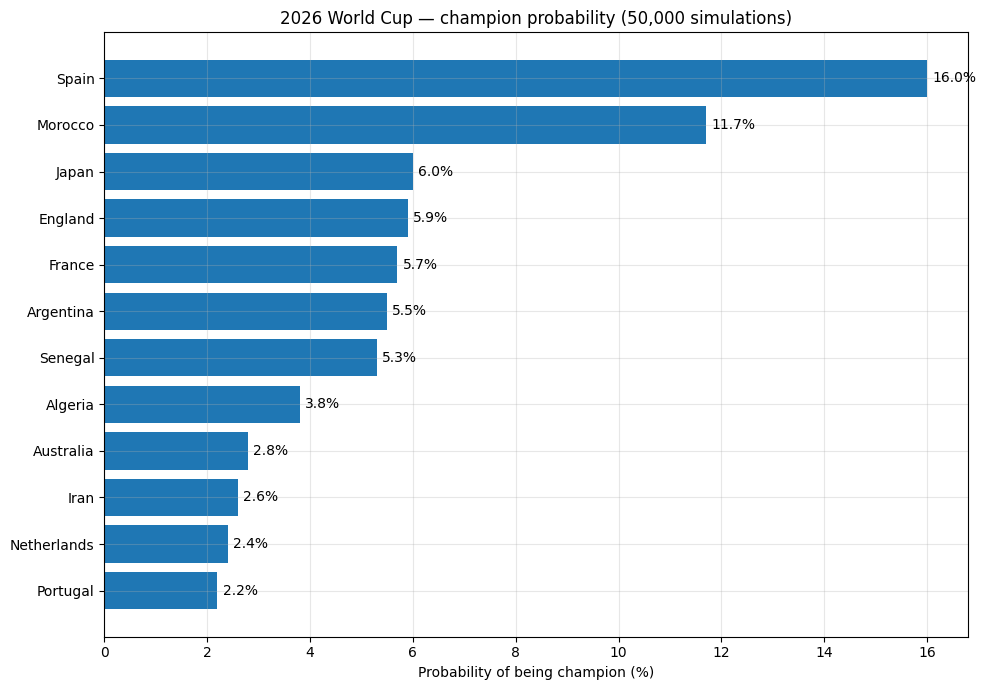

In [18]:
top12 = champ.head(12)[::-1]
plt.figure(figsize=(10, 7))
bars = plt.barh(top12.index, top12.values)
plt.xlabel("Probability of being champion (%)")
plt.title(f"2026 World Cup — champion probability ({N:,} simulations)")
for b, v in zip(bars, top12.values):
    plt.text(v + 0.1, b.get_y() + b.get_height() / 2, f"{v:.1f}%", va="center")
plt.tight_layout()
plt.show()

## 9. Colombia's path, round by round

The article's centrepiece: how far does Colombia go? We read the milestone probabilities straight off
the Monte Carlo table. Expect a monotonic decay — each round is strictly harder to reach than the last.


In [19]:
labels = {"r32": "Advance from group", "r16": "Round of 16", "qf": "Quarterfinals",
          "sf": "Semifinals", "final": "Final", "champion": "Champion"}

col = (results.loc["Colombia"] * 100).round(1)
col.index = [labels[k] for k in col.index]
col.to_frame("Colombia %")

,Colombia %
Advance from group,67.4
Round of 16,33.3
Quarterfinals,15.9
Semifinals,7.4
Final,3.2
Champion,1.4


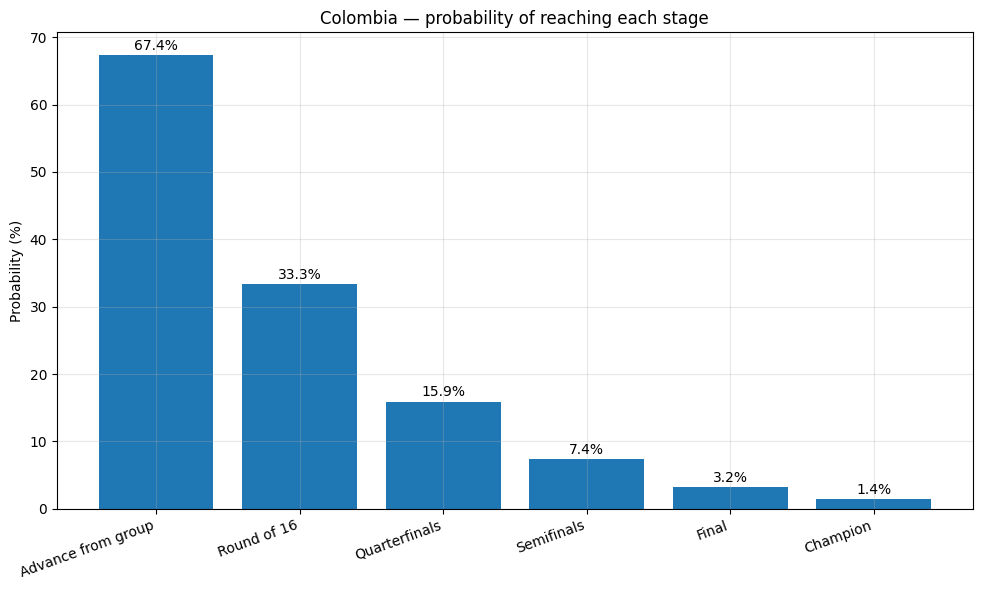

In [20]:
vals = (results.loc["Colombia"] * 100)
plt.figure(figsize=(10, 6))
order = ["r32", "r16", "qf", "sf", "final", "champion"]
plt.bar([labels[k] for k in order], [vals[k] for k in order])
plt.ylabel("Probability (%)")
plt.title("Colombia — probability of reaching each stage")
plt.xticks(rotation=20, ha="right")
for i, k in enumerate(order):
    plt.text(i, vals[k] + 0.8, f"{vals[k]:.1f}%", ha="center")
plt.tight_layout()
plt.show()

You can pull the same path for any team by changing the name:

In [21]:
def path(team):
    s = (results.loc[team] * 100).round(1)
    s.index = [labels[k] for k in s.index]
    return s.to_frame(f"{team} %")

path("Spain")

,Spain %
Advance from group,90.6
Round of 16,70.8
Quarterfinals,51.6
Semifinals,35.4
Final,23.9
Champion,16.0


## 11. Match-level breakdown

The analysis below reads directly from the tallies accumulated during the Monte Carlo.
No new simulation is needed — we just slice the counters.

### Group stage — fixture probabilities
`group_match_probs(group)` shows win/draw/loss percentages for every fixture in a group,
averaged over all `N` simulations. The numbers reflect the *pre-match* model probabilities
smoothed by `N` runs of Poisson noise, so they're slightly noisier than calling
`wdl_probabilities` directly — but they're grounded in the same model.


In [22]:
def group_match_probs(group_name):
    """Win/draw/loss % for every fixture in a group, averaged over the Monte Carlo."""
    teams = GROUPS[group_name]
    rows = []
    for i in range(len(teams)):
        for j in range(i + 1, len(teams)):
            a, b = teams[i], teams[j]
            r = grp_results[a][b]
            played = r["win"] + r["draw"] + r["loss"]
            if played == 0:
                continue
            rows.append({
                "fixture":       f"{a}  vs  {b}",
                f"{a} win %":   round(100 * r["win"]  / played, 1),
                "draw %":        round(100 * r["draw"] / played, 1),
                f"{b} win %":   round(100 * r["loss"] / played, 1),
            })
    return pd.DataFrame(rows).set_index("fixture")


# All three fixtures in Group K (Colombia's group)
group_match_probs("K")


,Portugal win %,draw %,Colombia win %,Uzbekistan win %,DR Congo win %
fixture,,,,,
Portugal vs Colombia,39.3,25.9,34.8,NaN,NaN
Portugal vs Uzbekistan,40.0,26.1,NaN,33.9,NaN
Portugal vs DR Congo,40.7,26.3,NaN,NaN,33.0
Colombia vs Uzbekistan,NaN,26.3,37.7,36.0,NaN
Colombia vs DR Congo,NaN,25.9,38.4,NaN,35.6
Uzbekistan vs DR Congo,NaN,26.1,NaN,37.7,36.3


In [23]:
# You can inspect any group — e.g. the "group of death"
group_match_probs("I")   # France / Senegal / Norway / Iraq


,France win %,draw %,Senegal win %,Norway win %,Iraq win %
fixture,,,,,
France vs Senegal,37.4,26.2,36.4,NaN,NaN
France vs Norway,43.6,25.7,NaN,30.7,NaN
France vs Iraq,50.3,24.8,NaN,NaN,24.9
Senegal vs Norway,NaN,25.9,42.6,31.6,NaN
Senegal vs Iraq,NaN,25.1,49.9,NaN,25.0
Norway vs Iraq,NaN,25.5,NaN,44.5,30.0


### Knockout stage — head-to-head across all rounds
`ko_h2h(team)` shows every opponent `team` faced in the knockout rounds across all
`N` simulations, how many times they met, and the win rate. This answers: *when Colombia
reached the knockout, who did they tend to meet — and how often did they advance?*


In [24]:
def ko_h2h(team):
    """How team fared against each opponent across all knockout encounters."""
    if not ko_results[team] and not any(team in v for v in ko_results.values()):
        print(f"{team} never appeared in the knockout in these simulations.")
        return pd.DataFrame()
    rows = []
    all_opps = set(ko_results[team].keys()) | {o for o,v in ko_results.items() if team in v}
    for opp in sorted(all_opps, key=lambda o: -(ko_results[team].get(o,0) + ko_results[o].get(team,0))):
        wins   = ko_results[team].get(opp, 0)
        losses = ko_results[opp].get(team, 0)
        total  = wins + losses
        if total == 0:
            continue
        rows.append({
            "opponent":   opp,
            "meetings":   total,
            "win %":      round(100 * wins   / total, 1),
            "loss %":     round(100 * losses / total, 1),
        })
    return pd.DataFrame(rows).set_index("opponent")


ko_h2h("Colombia")


,meetings,win %,loss %
opponent,,,
England,4535,36.4,63.6
Algeria,4270,41.3,58.7
Argentina,4221,37.6,62.4
Panama,4019,51.6,48.4
Croatia,3988,52.4,47.6
Jordan,3287,53.5,46.5
Austria,2933,56.9,43.1
France,2639,37.0,63.0
Senegal,2513,37.0,63.0


In [25]:
ko_h2h("Spain")


,meetings,win %,loss %
opponent,,,
Switzerland,9713,74.3,25.7
Canada,9600,75.6,24.4
Australia,7305,67.9,32.1
Bosnia and Herzegovina,6133,90.6,9.4
Iran,5866,68.9,31.1
Qatar,5645,91.2,8.8
Morocco,5401,54.7,45.3
Turkey,5033,73.5,26.5
Egypt,4941,71.0,29.0


### Knockout encounters broken down by round
`ko_round_detail(team)` shows the same data split by round — useful for seeing
*where* in the bracket a team's journey typically ended.


In [26]:
ROUND_LABELS = {
    "r32": "Round of 32", "r16": "Round of 16",
    "qf":  "Quarterfinal", "sf":  "Semifinal", "final": "Final",
}
ROUND_ORDER = list(ROUND_LABELS.values())

def ko_round_detail(team):
    """Per-round KO record: who team beat and who knocked them out, in bracket order."""
    rows = []
    for rnd, label in ROUND_LABELS.items():
        for opp, cnt in ko_by_round[rnd][team].items():
            rows.append({"round": label, "result": "Win",  "opponent": opp, "count": cnt})
        for winner, losers in ko_by_round[rnd].items():
            if team in losers:
                rows.append({"round": label, "result": "Loss", "opponent": winner, "count": losers[team]})
    if not rows:
        return pd.DataFrame()
    df = pd.DataFrame(rows)
    df["round"] = pd.Categorical(df["round"], categories=ROUND_ORDER, ordered=True)
    return (df.sort_values(["round", "result", "count"], ascending=[True, True, False])
              .reset_index(drop=True))


ko_round_detail("Colombia")


,round,result,opponent,count
0,Round of 32,Loss,England,2475
1,Round of 32,Loss,Argentina,2169
2,Round of 32,Loss,Algeria,2126
3,Round of 32,Loss,Panama,1775
4,Round of 32,Loss,Croatia,1720
...,...,...,...,...
435,Final,Win,South Africa,2
436,Final,Win,Saudi Arabia,2
437,Final,Win,Cape Verde,2
438,Final,Win,United States,2


In [27]:
ko_round_detail("Colombia").value_counts()

round        result  opponent       count
Round of 32  Loss    Algeria        2126     1
                     Argentina      2169     1
                     Australia      236      1
                     Austria        1151     1
                     Belgium        115      1
                                            ..
Final        Win     Tunisia        5        1
                     Turkey         10       1
                     United States  2        1
                     Uruguay        3        1
                     Uzbekistan     7        1
Name: count, Length: 440, dtype: int64

C:\Users\luiscarlos.gaitan\AppData\Local\Temp\ipykernel_14440\774823457.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  wins_df  = detail[detail["result"] == "Win"].groupby("round")["count"].sum()
C:\Users\luiscarlos.gaitan\AppData\Local\Temp\ipykernel_14440\774823457.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  losses_df = detail[detail["result"] == "Loss"].groupby("round")["count"].sum()


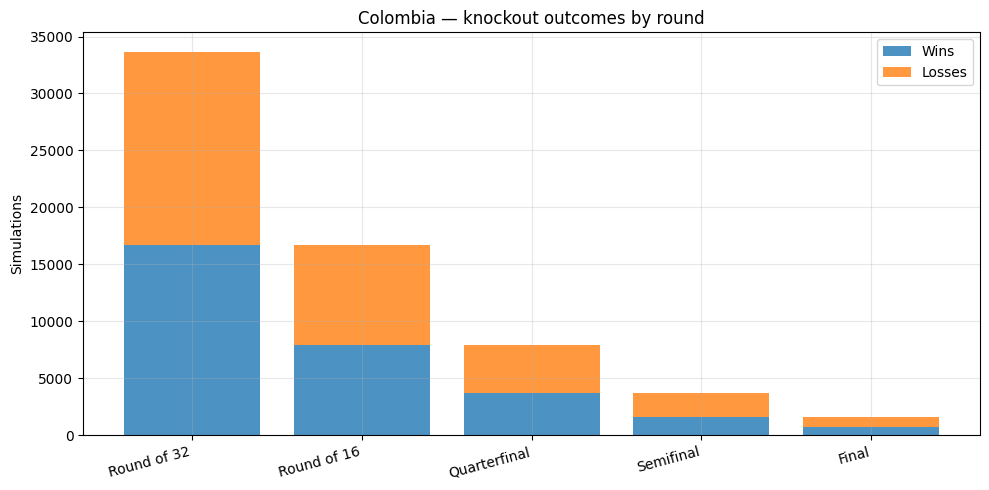

: 

In [ ]:
# Bar chart: Colombia's most common KO opponents by round
detail = ko_round_detail("Colombia")
if not detail.empty:
    wins_df  = detail[detail["result"] == "Win"].groupby("round")["count"].sum()
    losses_df = detail[detail["result"] == "Loss"].groupby("round")["count"].sum()
    rnd_order = list(ROUND_LABELS.values())
    w = [wins_df.get(r, 0) for r in rnd_order]
    l = [losses_df.get(r, 0) for r in rnd_order]

    x = range(len(rnd_order))
    plt.figure(figsize=(10, 5))
    plt.bar(x, w, label="Wins", alpha=0.8)
    plt.bar(x, l, bottom=w, label="Losses", alpha=0.8)
    plt.xticks(x, rnd_order, rotation=15, ha="right")
    plt.ylabel("Simulations")
    plt.title("Colombia — knockout outcomes by round")
    plt.legend()
    plt.tight_layout()
    plt.show()


## 10. What the model cannot see

Worth stating plainly, as the original does:

- **No expected goals (xG).** It works off final results, not chance quality. A team that wins ugly and a team that dominates and wins look identical to ELO.
- **No squad information.** Injuries, suspensions, a player's current form — none of it is in a national-team rating.
- **No host effect.** Crowd, travel, familiarity with stadiums: not modelled. (The USA's rating leaves them eliminated in the Round of 32 roughly half the time, which intuitively feels too harsh — but that's what a pure-results model says.)
- **The bracket approximation** of Section 6, and the fact that ELO has no notion of *recent* momentum beyond what the K-factor and decay already encode.

And the honest framing the author closes on: the model says one team is the *most likely* winner, while simultaneously saying it's far more likely that *that team does not win* than that it does. That's not a contradiction — it's just what "favourite in a 48-team knockout" actually means.

---

### Things to try next
- Bump `N` to `50_000` and compare the champion table to the article.
- Swap the **logarithmic** goal multiplier for the eloratings.net step version (`G=1.5` at 2 goals, `(11+|gd|)/8` for 3+) and watch the rating spread change.
- Make the Poisson `λ`s a sharper function of the rating gap and see how much it concentrates the title odds.
- Replace the simplified third-place allocation with FIFA's full lookup table for an exact bracket.
